# HW 6 m4 cluster with DNN

Demonstrate the use of a densely connected neural network, like the one we trained on the MNIST data set, for classifying stars in the M4 cluster using Gaia's measurements of stars' locations on the sky (right ascension and declination).  This is basically a repeat of what we covered in class, but this time I want you to even out the training set to include roughly equal numbers of M4 members and non-members.

In [1]:
import numpy as np

import jax
import jax.numpy as jnp

import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from flax import linen as nn

In [7]:
# import data 
m4_df = pd.read_fwf('../../../data/NGC6121-1.dat', names=['source_id', 'ra', 'dec', 'phot_g_mean_mag'])
m4_df

,source_id,ra,dec,phot_g_mean_mag
0,6045504229661220736,245.99162,-26.34434,18.438
1,6045504981264184192,246.03035,-26.28057,18.769
2,6045508902585952640,245.88761,-26.24297,19.072
3,6045507180287440000,245.85343,-26.28453,18.495
4,6045503473747038464,245.87124,-26.34628,17.163
...,...,...,...,...
19503,6045337962873610240,245.13976,-27.09970,19.705
19504,6045298891556291712,245.48339,-27.19208,19.493
19505,6045305866578950784,245.69445,-27.06942,18.290
19506,6045303774938119808,245.80824,-27.07275,19.267


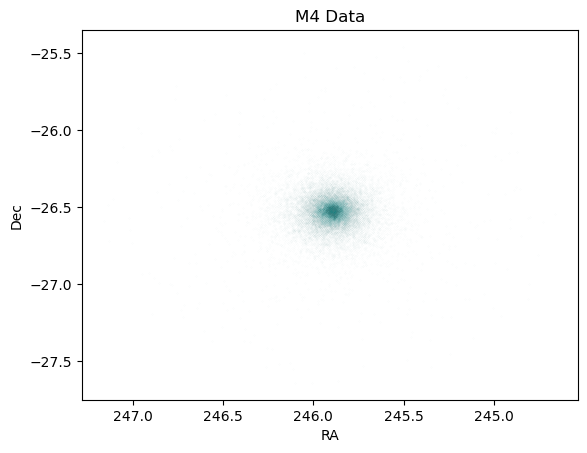

In [9]:
plt.scatter(m4_df.ra, m4_df.dec, s=0.0001, color='teal')
plt.title('M4 Data')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()

In [12]:
df = pd.read_csv('../../../../hub_data_share/m4_gaia_source.csv')
df.head()

,designation,source_id,ra,dec,parallax,parallax_error,parallax_over_error,pm,pmra,pmra_error,...,phot_g_mean_flux_over_error,phot_g_mean_mag,phot_bp_mean_flux_over_error,phot_bp_mean_mag,phot_rp_mean_flux_over_error,phot_rp_mean_mag,phot_bp_rp_excess_factor,bp_rp,radial_velocity,radial_velocity_error
0,Gaia DR3 6048466004733106048,6048466004733106048,244.500044,-26.152984,2.274643,1.125653,2.020732,8.490148,-7.892926,1.880442,...,110.199646,20.722200,4.511861,21.159956,17.483234,19.606243,1.661088,1.553713,NaN,NaN
1,Gaia DR3 6048666665606296064,6048666665606296064,244.500060,-25.906141,0.632528,0.769472,0.822029,2.582879,-0.097646,0.931963,...,178.075440,20.311983,10.519053,21.239437,20.069353,19.297583,1.380115,1.941855,NaN,NaN
2,Gaia DR3 6048358561832132864,6048358561832132864,244.500066,-26.918531,1.153917,0.907036,1.272184,7.455110,-5.327529,1.236975,...,152.003370,20.567377,7.892730,21.225716,16.701073,19.618095,1.404567,1.607620,NaN,NaN
3,Gaia DR3 6048842759265408128,6048842759265408128,244.500077,-25.216618,NaN,NaN,NaN,NaN,NaN,NaN,...,68.553120,20.875511,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Gaia DR3 6048837635368203648,6048837635368203648,244.500085,-25.318745,0.405547,0.118409,3.424970,1.204035,-0.644142,0.158066,...,959.558700,17.849728,73.395320,18.590256,129.001560,16.973124,1.310396,1.617132,NaN,NaN


In [14]:
df.columns

Index(['designation', 'source_id', 'ra', 'dec', 'parallax', 'parallax_error',
       'parallax_over_error', 'pm', 'pmra', 'pmra_error', 'pmdec',
       'pmdec_error', 'astrometric_n_good_obs_al', 'astrometric_chi2_al',
       'visibility_periods_used', 'phot_g_mean_flux_over_error',
       'phot_g_mean_mag', 'phot_bp_mean_flux_over_error', 'phot_bp_mean_mag',
       'phot_rp_mean_flux_over_error', 'phot_rp_mean_mag',
       'phot_bp_rp_excess_factor', 'bp_rp', 'radial_velocity',
       'radial_velocity_error'],
      dtype='object')

that's a lot!

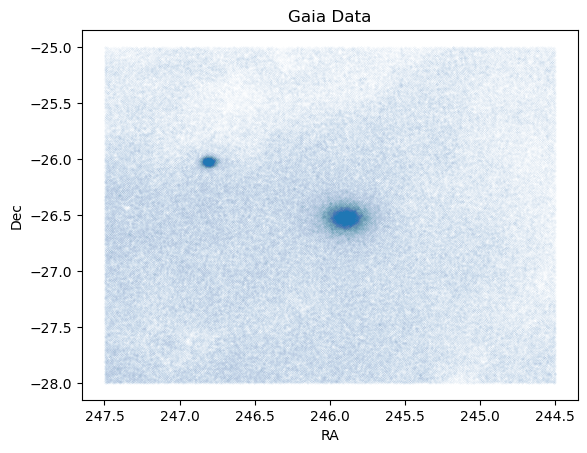

In [15]:
plt.scatter(df.ra, df.dec, s=0.0001)
plt.gca().invert_xaxis()
plt.title('Gaia Data')
plt.xlabel('RA')
plt.ylabel('Dec');

## 1) Cross-Matching between two data sets

In [16]:
m4_sel = df['source_id'].isin(m4_df.source_id)
print(np.count_nonzero(m4_sel))
print(np.count_nonzero(~m4_sel))

19084
475912


pink is not a member, purple is a member


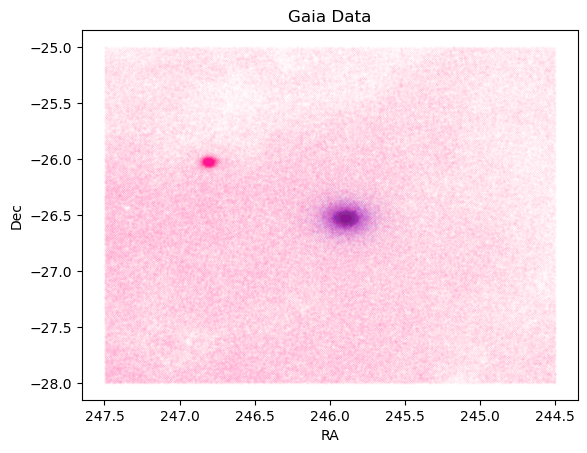

In [23]:
print('pink is not a member, purple is a member')
plt.scatter(df.ra[~m4_sel], df.dec[~m4_sel], s=0.0001, color='deeppink')
plt.scatter(df.ra[m4_sel], df.dec[m4_sel], s=0.0001, color='blueviolet')
plt.gca().invert_xaxis()
plt.title('Gaia Data')
plt.xlabel('RA')
plt.ylabel('Dec');

In [29]:
# create a df of just RA and Dec
# this is defining RA and Dec as our features
params = ['ra', 'dec']
X = np.array(df[params])


# classify M4 membership as in (1) or out (0)
y = m4_sel.astype(int)

# remove rows with missing values of RA or Dec
nans = np.any(np.isnan(X), axis=1)
X = X[~nans]
y = y[~nans]

# make masks for each class to split the rows into members and nonmebers
m4_mask = y == 1
non_mask = y == 0

# split feature arrays by class
X_m4 = np.array(X[m4_mask]) # all features for M4 stars
y_m4 = np.array(y[m4_mask]) # all features for non-M4 stars
X_non = np.array(X[non_mask]) # corresponding labels
y_non = np.array(y[non_mask])

n = X_m4.shape[0]
idx = np.random.choice(X_non.shape[0], size=n, replace=False)
X_non = X_non[idx]
y_non = y_non[idx]

X = np.concatenate((X_m4, X_non))
y = np.concatenate((y_m4, y_non))
print(f'X.shape: {X.shape}\ny.shape: {y.shape}')


X.shape: (38168, 2)
y.shape: (38168,)


In [31]:
from sklearn.model_selection import train_test_split
# hannah said to do this and I beleive her
indices = np.arange(X.shape[0])
X_train, X_tst, y_train, y_tst, train_idx, test_idx = train_test_split(X, y, indices, test_size=0.1, shuffle=True, random_state=42)

In [32]:
from sklearn.preprocessing import StandardScaler

In [34]:
transformer = StandardScaler()

X_train = transformer.fit_transform(X_train)
X_tst = transformer.fit_transform(X_tst)

# make some arrays
X_train = jnp.array(X_train)
X_tst = jnp.array(X_tst)
y_train = jnp.array(y_train)
y_tst = jnp.array(y_tst)

# Data batching!!
batch_size = 64
n_batches = X_train.shape[0] // batch_size

X_train = X_train[:n_batches * batch_size].reshape((n_batches, batch_size, *X_train.shape[1:]))
y_train = y_train[:n_batches * batch_size].reshape((n_batches, batch_size, *y_train.shape[1:]))
X_train.shape, y_train.shape

((536, 64, 2), (536, 64))

In [34]:
transformer = StandardScaler()

X_train = transformer.fit_transform(X_train)
X_tst = transformer.fit_transform(X_tst)

# make some arrays
X_train = jnp.array(X_train)
X_tst = jnp.array(X_tst)
y_train = jnp.array(y_train)
y_tst = jnp.array(y_tst)

# Data batching!!
batch_size = 64
n_batches = X_train.shape[0] // batch_size

X_train = X_train[:n_batches * batch_size].reshape((n_batches, batch_size, *X_train.shape[1:]))
y_train = y_train[:n_batches * batch_size].reshape((n_batches, batch_size, *y_train.shape[1:]))
X_train.shape, y_train.shape

((536, 64, 2), (536, 64))

### Time for model training

a lot of this is copy and paste from the DNN construction from DNN Classifiers lecture

In [36]:
n_classes = 2

class DenseClassifier(nn.Module):
    """A simple dense classifier."""

    @nn.compact
    def __call__(self, x):
        x = nn.Dense(10)(x)
        x = nn.relu(x)
        x = nn.Dense(10)(x)
        x = nn.relu(x)
        x = nn.Dense(n_classes)(x)
        return x

dummy_input = jnp.ones((1, 2))
dnn = DenseClassifier()
print(dnn.tabulate(jax.random.PRNGKey(0), dummy_input))


                            DenseClassifier Summary                             
┏━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ path    ┃ module          ┃ inputs        ┃ outputs       ┃ params           ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│         │ DenseClassifier │ float32[1,2]  │ float32[1,2]  │                  │
├─────────┼─────────────────┼───────────────┼───────────────┼──────────────────┤
│ Dense_0 │ Dense           │ float32[1,2]  │ float32[1,10] │ bias:            │
│         │                 │               │               │ float32[10]      │
│         │                 │               │               │ kernel:          │
│         │                 │               │               │ float32[2,10]    │
│         │                 │               │               │                  │
│         │                 │               │               │ 30 (120 B)       │
├─────────┼────────────────

In [37]:
X_train.shape, y_train.shape

((536, 64, 2), (536, 64))

In [38]:
from clu import metrics
from flax.training import train_state
from flax import struct
import optax

In [39]:
@struct.dataclass
class Metrics(metrics.Collection):
    accuracy: metrics.Accuracy
    loss: metrics.Average.from_output('loss')

class TrainState(train_state.TrainState):
   metrics: Metrics

def create_train_state(model, rng, learning_rate):
    params = model.init(rng, dummy_input)['params']
    tx = optax.adam(learning_rate)
    return TrainState.create(
        apply_fn=model.apply, params=params, tx=tx,
        metrics=Metrics.empty())

@jax.jit
def train_step(state, batch, label):
  """Train for a single step."""
  def loss_fn(params):
    logits = state.apply_fn({'params': params}, batch)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=label).mean()
    return loss
  grad_fn = jax.grad(loss_fn)
  grads = grad_fn(state.params)
  state = state.apply_gradients(grads=grads)
  return state

@jax.jit
def compute_metrics(*, state, batch, label):
    logits = state.apply_fn({'params': state.params}, batch)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=label).mean()
    metric_updates = state.metrics.single_from_model_output(
        logits=logits, labels=label, loss=loss)
    metrics = state.metrics.merge(metric_updates)
    state = state.replace(metrics=metrics)
    return state

init_rng = jax.random.PRNGKey(0)

learning_rate = 0.01

state = create_train_state(dnn, init_rng, learning_rate)
del init_rng  # Must not be used anymore.

metrics_history = {'train_loss': [],
                   'train_accuracy': [],
                   'test_loss': [],
                   'test_accuracy': []}

In [40]:
n_epochs = 50

step = 0

for _ in range(n_epochs):
  for batch, label in zip(X_train, y_train):

    # Run optimization steps over training batches and compute batch metrics
    state = train_step(state, batch, label) # get updated train state (which contains the updated parameters)
    state = compute_metrics(state=state, batch=batch, label=label) # aggregate batch metrics

    if (step+1) % n_batches == 0: # one training epoch has passed
      for metric,value in state.metrics.compute().items(): # compute metrics
        metrics_history[f'train_{metric}'].append(value) # record metrics
      state = state.replace(metrics=state.metrics.empty()) # reset train_metrics for next training epoch

      # Compute metrics on the test set after each training epoch
      test_state = state
      test_state = compute_metrics(state=test_state, batch=X_tst, label=y_tst)

      for metric,value in test_state.metrics.compute().items():
        metrics_history[f'test_{metric}'].append(value)

      print(f"train epoch: {(step+1) // n_batches}, "
            f"loss: {metrics_history['train_loss'][-1]}, "
            f"accuracy: {metrics_history['train_accuracy'][-1] * 100}")
      print(f"test epoch: {(step+1) // n_batches}, "
            f"loss: {metrics_history['test_loss'][-1]}, "
            f"accuracy: {metrics_history['test_accuracy'][-1] * 100}")
    step += 1
  

train epoch: 1, loss: 0.21527178585529327, accuracy: 92.8463134765625
test epoch: 1, loss: 0.21305212378501892, accuracy: 93.03117370605469
train epoch: 2, loss: 0.20277279615402222, accuracy: 93.24276733398438
test epoch: 2, loss: 0.211643785238266, accuracy: 93.10977172851562
train epoch: 3, loss: 0.20212049782276154, accuracy: 93.27484130859375
test epoch: 3, loss: 0.21082048118114471, accuracy: 93.057373046875
train epoch: 4, loss: 0.20160678029060364, accuracy: 93.24276733398438
test epoch: 4, loss: 0.21029351651668549, accuracy: 93.00497436523438
train epoch: 5, loss: 0.20145517587661743, accuracy: 93.27192687988281
test epoch: 5, loss: 0.2102964073419571, accuracy: 93.03117370605469
train epoch: 6, loss: 0.20119990408420563, accuracy: 93.2573471069336
test epoch: 6, loss: 0.20996198058128357, accuracy: 93.057373046875
train epoch: 7, loss: 0.20104549825191498, accuracy: 93.25443267822266
test epoch: 7, loss: 0.20961059629917145, accuracy: 93.03117370605469
train epoch: 8, loss: 

In [41]:
print('Mean training accuracy: %.3f' % np.mean(metrics_history['train_accuracy']))
print('Mean testing accuracy: %.3f' % np.mean(metrics_history['test_accuracy']))

Mean training accuracy: 0.932
Mean testing accuracy: 0.930


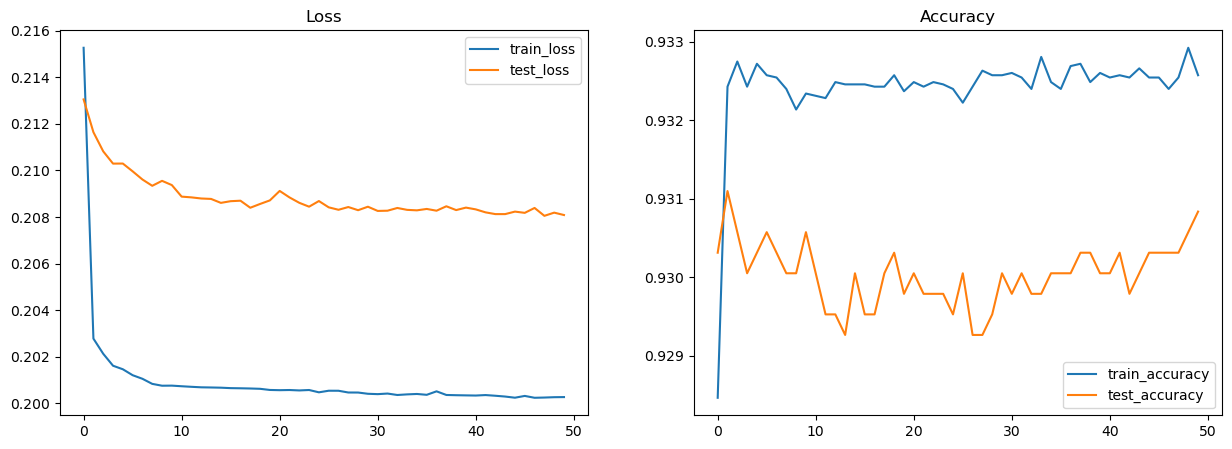

<Figure size 640x480 with 0 Axes>

In [44]:
# Plot loss and accuracy in subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.set_title('Loss')
ax2.set_title('Accuracy')
for dataset in ('train','test'):
  ax1.plot(metrics_history[f'{dataset}_loss'], label=f'{dataset}_loss')
  ax2.plot(metrics_history[f'{dataset}_accuracy'], label=f'{dataset}_accuracy')
ax1.legend()
ax2.legend()
plt.show()
plt.clf();

In [45]:
@jax.jit
def pred_step(state, batch):
  logits = state.apply_fn({'params': state.params}, batch)
  return logits.argmax(axis=1)

pred = pred_step(state, X_tst)
pred

Array([1, 1, 1, ..., 0, 1, 0], dtype=int32)

(array([1781.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        2036.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

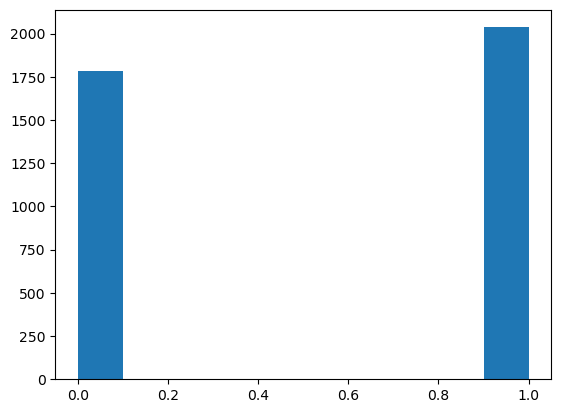

In [46]:
plt.hist(pred)

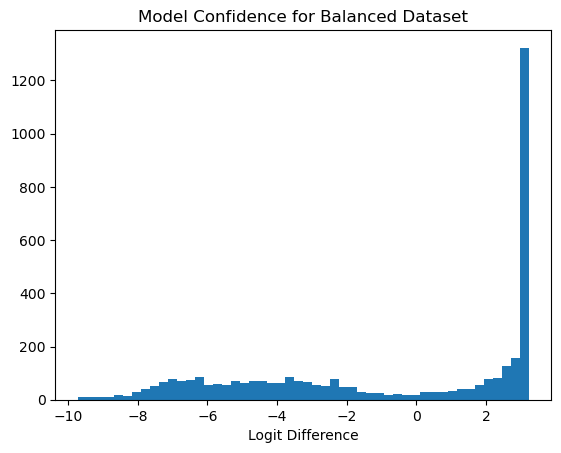

In [49]:
outputs = state.apply_fn({'params': state.params}, X_tst)
plt.hist(jnp.diff(outputs, axis=1).flatten(), bins=50)
plt.title('Model Confidence for Balanced Dataset')
plt.xlabel('Logit Difference');

In [54]:
ra_full = df['ra'][~nans].to_numpy()
dec_full = df['dec'][~nans].to_numpy()
ra_m4 = np.array(ra_full[m4_mask])
ra_non = np.array(ra_full[non_mask])
ra_non = ra_non[idx]
dec_m4 = np.array(dec_full[m4_mask])
dec_non = np.array(dec_full[non_mask])
dec_non = dec_non[idx]
ra = np.concatenate((ra_m4, ra_non))
dec = np.concatenate((dec_m4, dec_non))
print(ra.shape, dec.shape)

(38168,) (38168,)


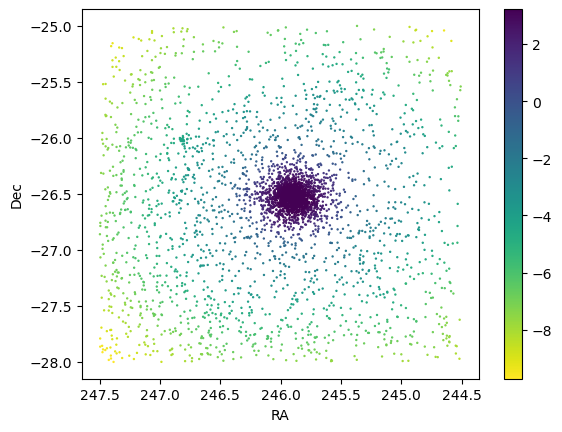

In [55]:
plt.scatter(ra[test_idx], dec[test_idx], c=jnp.diff(outputs, axis=1), s=0.5, cmap='viridis_r')
# plt.title('Balanced Dataset')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()
plt.colorbar()

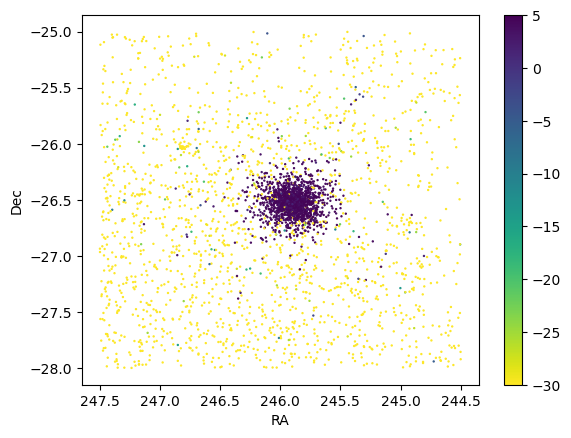

In [75]:
plt.scatter(ra[test_idx], dec[test_idx], c=jnp.diff(outputs, axis=1), s=0.5, cmap='viridis_r', vmin=-30, vmax=5)
# plt.title('Balanced Dataset with Proper Motion and Parallax')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()
plt.colorbar()

## Questions

1. What training and validation accuracies are you able to achieve?

2. Is your trained model confident that any of the stars in your test set are part of M4?

3. What did your model learn?  Can you come up with a useful way to probe your model and visualize the results to answer this question?

4. Do you think more sophisticated models could do better with this classification task using only sky positions?  Use the properties of the training set to make your argument.

## Extra Work for Grads ;P

Make use of other features observed by Gaia to improve your classifier.  Be sure to use the data model documentation to understand what each feature is, and **explain why you think it would be useful for identifying cluster members.**  What training and validation accuracies can you achieve?  Does your trained model find any stars it believes are confidently in M4 that weren't in the M4 catalog?

In [56]:
# much of the bulk of the code is the same
# we start by updating our features

# this is defining RA and Dec as our features
params = ['ra', 'dec', 'pmra', 'pmdec']
X = np.array(df[params])


# classify M4 membership as in (1) or out (0)
y = m4_sel.astype(int)

# remove rows with missing values of RA or Dec
nans = np.any(np.isnan(X), axis=1)
X = X[~nans]
y = y[~nans]

# make masks for each class to split the rows into members and nonmebers
m4_mask = y == 1
non_mask = y == 0

# split feature arrays by class
X_m4 = np.array(X[m4_mask]) # all features for M4 stars
y_m4 = np.array(y[m4_mask]) # all features for non-M4 stars
X_non = np.array(X[non_mask]) # corresponding labels
y_non = np.array(y[non_mask])

n = X_m4.shape[0]
idx = np.random.choice(X_non.shape[0], size=n, replace=False)
X_non = X_non[idx]
y_non = y_non[idx]

X = np.concatenate((X_m4, X_non))
y = np.concatenate((y_m4, y_non))
print(f'X.shape: {X.shape}\ny.shape: {y.shape}')

X.shape: (38038, 4)
y.shape: (38038,)


In [57]:
from sklearn.model_selection import train_test_split
# hannah said to do this and I beleive her
indices = np.arange(X.shape[0])
X_train, X_tst, y_train, y_tst, train_idx, test_idx = train_test_split(X, y, indices, test_size=0.1, shuffle=True, random_state=42)

In [58]:
transformer = StandardScaler()

X_train = transformer.fit_transform(X_train)
X_tst = transformer.fit_transform(X_tst)

# make some arrays
X_train = jnp.array(X_train)
X_tst = jnp.array(X_tst)
y_train = jnp.array(y_train)
y_tst = jnp.array(y_tst)

# Data batching!!
batch_size = 64
n_batches = X_train.shape[0] // batch_size

X_train = X_train[:n_batches * batch_size].reshape((n_batches, batch_size, *X_train.shape[1:]))
y_train = y_train[:n_batches * batch_size].reshape((n_batches, batch_size, *y_train.shape[1:]))
X_train.shape, y_train.shape

((534, 64, 4), (534, 64))

In [63]:
n_classes = 2

class DenseClassifier(nn.Module):
    """A simple dense classifier."""

    @nn.compact
    def __call__(self, x):
        x = nn.Dense(10)(x)
        x = nn.relu(x)
        x = nn.Dense(10)(x)
        x = nn.relu(x)
        x = nn.Dense(n_classes)(x)
        return x

dummy_input = jnp.ones((1, 4))
dnn = DenseClassifier()
print(dnn.tabulate(jax.random.PRNGKey(0), dummy_input))


                            DenseClassifier Summary                             
┏━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ path    ┃ module          ┃ inputs        ┃ outputs       ┃ params           ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│         │ DenseClassifier │ float32[1,4]  │ float32[1,2]  │                  │
├─────────┼─────────────────┼───────────────┼───────────────┼──────────────────┤
│ Dense_0 │ Dense           │ float32[1,4]  │ float32[1,10] │ bias:            │
│         │                 │               │               │ float32[10]      │
│         │                 │               │               │ kernel:          │
│         │                 │               │               │ float32[4,10]    │
│         │                 │               │               │                  │
│         │                 │               │               │ 50 (200 B)       │
├─────────┼────────────────

In [64]:
X_train.shape, y_train.shape

((534, 64, 4), (534, 64))

In [65]:
@struct.dataclass
class Metrics(metrics.Collection):
    accuracy: metrics.Accuracy
    loss: metrics.Average.from_output('loss')

class TrainState(train_state.TrainState):
   metrics: Metrics

def create_train_state(model, rng, learning_rate):
    params = model.init(rng, dummy_input)['params']
    tx = optax.adam(learning_rate)
    return TrainState.create(
        apply_fn=model.apply, params=params, tx=tx,
        metrics=Metrics.empty())

@jax.jit
def train_step(state, batch, label):
  """Train for a single step."""
  def loss_fn(params):
    logits = state.apply_fn({'params': params}, batch)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=label).mean()
    return loss
  grad_fn = jax.grad(loss_fn)
  grads = grad_fn(state.params)
  state = state.apply_gradients(grads=grads)
  return state

@jax.jit
def compute_metrics(*, state, batch, label):
    logits = state.apply_fn({'params': state.params}, batch)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=label).mean()
    metric_updates = state.metrics.single_from_model_output(
        logits=logits, labels=label, loss=loss)
    metrics = state.metrics.merge(metric_updates)
    state = state.replace(metrics=metrics)
    return state

init_rng = jax.random.PRNGKey(0)

learning_rate = 0.01

state = create_train_state(dnn, init_rng, learning_rate)
del init_rng  # Must not be used anymore.

metrics_history = {'train_loss': [],
                   'train_accuracy': [],
                   'test_loss': [],
                   'test_accuracy': []}

In [66]:
n_epochs = 50

step = 0

for _ in range(n_epochs):
  for batch, label in zip(X_train, y_train):

    # Run optimization steps over training batches and compute batch metrics
    state = train_step(state, batch, label) # get updated train state (which contains the updated parameters)
    state = compute_metrics(state=state, batch=batch, label=label) # aggregate batch metrics

    if (step+1) % n_batches == 0: # one training epoch has passed
      for metric,value in state.metrics.compute().items(): # compute metrics
        metrics_history[f'train_{metric}'].append(value) # record metrics
      state = state.replace(metrics=state.metrics.empty()) # reset train_metrics for next training epoch

      # Compute metrics on the test set after each training epoch
      test_state = state
      test_state = compute_metrics(state=test_state, batch=X_tst, label=y_tst)

      for metric,value in test_state.metrics.compute().items():
        metrics_history[f'test_{metric}'].append(value)

      print(f"train epoch: {(step+1) // n_batches}, "
            f"loss: {metrics_history['train_loss'][-1]}, "
            f"accuracy: {metrics_history['train_accuracy'][-1] * 100}")
      print(f"test epoch: {(step+1) // n_batches}, "
            f"loss: {metrics_history['test_loss'][-1]}, "
            f"accuracy: {metrics_history['test_accuracy'][-1] * 100}")
    step += 1
  

train epoch: 1, loss: 0.07514356821775436, accuracy: 98.27949523925781
test epoch: 1, loss: 0.049031227827072144, accuracy: 98.76445770263672
train epoch: 2, loss: 0.05553757771849632, accuracy: 98.64524841308594
test epoch: 2, loss: 0.047544367611408234, accuracy: 98.89590454101562
train epoch: 3, loss: 0.05440108850598335, accuracy: 98.6511001586914
test epoch: 3, loss: 0.045820172876119614, accuracy: 98.89590454101562
train epoch: 4, loss: 0.053454261273145676, accuracy: 98.67742919921875
test epoch: 4, loss: 0.04562690481543541, accuracy: 98.89590454101562
train epoch: 5, loss: 0.05283685773611069, accuracy: 98.70084381103516
test epoch: 5, loss: 0.04397234320640564, accuracy: 99.00105285644531
train epoch: 6, loss: 0.05211087316274643, accuracy: 98.70084381103516
test epoch: 6, loss: 0.044763900339603424, accuracy: 98.97476196289062
train epoch: 7, loss: 0.05194195732474327, accuracy: 98.7125473022461
test epoch: 7, loss: 0.04418303444981575, accuracy: 99.00105285644531
train epoc

In [67]:
print('Mean training accuracy: %.3f' % np.mean(metrics_history['train_accuracy']))
print('Mean testing accuracy: %.3f' % np.mean(metrics_history['test_accuracy']))

Mean training accuracy: 0.987
Mean testing accuracy: 0.990


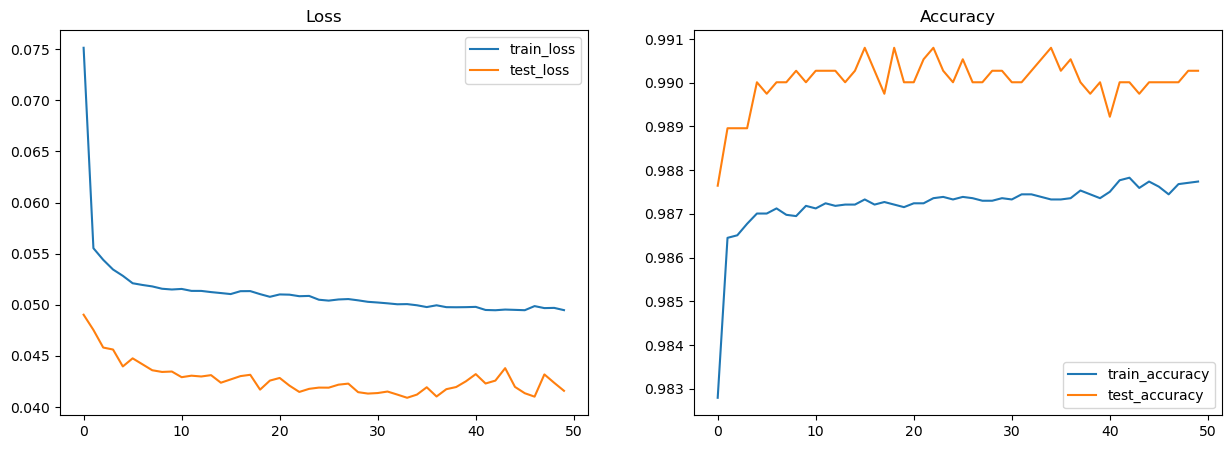

<Figure size 640x480 with 0 Axes>

In [68]:
# Plot loss and accuracy in subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.set_title('Loss')
ax2.set_title('Accuracy')
for dataset in ('train','test'):
  ax1.plot(metrics_history[f'{dataset}_loss'], label=f'{dataset}_loss')
  ax2.plot(metrics_history[f'{dataset}_accuracy'], label=f'{dataset}_accuracy')
ax1.legend()
ax2.legend()
plt.show()
plt.clf();

In [69]:
@jax.jit
def pred_step(state, batch):
  logits = state.apply_fn({'params': state.params}, batch)
  return logits.argmax(axis=1)

pred = pred_step(state, X_tst)
pred

Array([0, 1, 0, ..., 1, 1, 0], dtype=int32)

(array([1871.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        1933.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

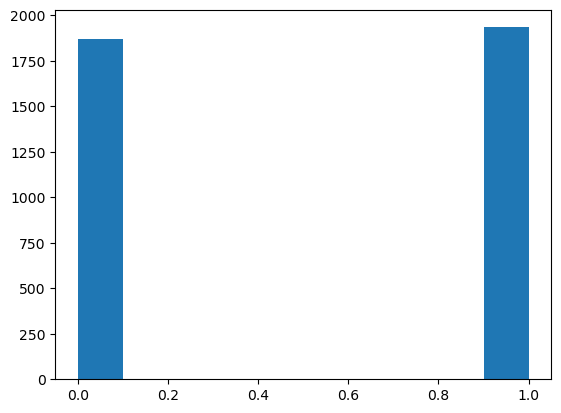

In [70]:
plt.hist(pred)

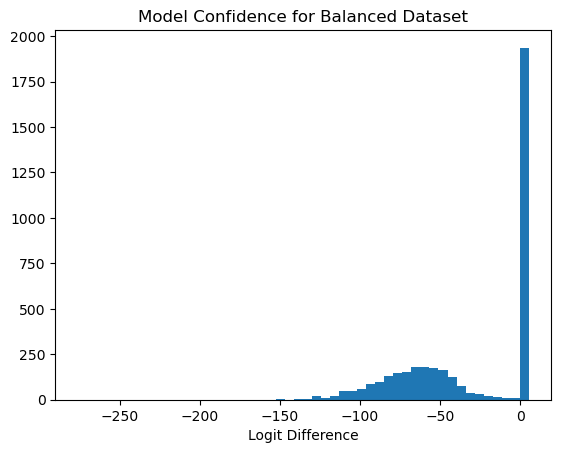

In [71]:
outputs = state.apply_fn({'params': state.params}, X_tst)
plt.hist(jnp.diff(outputs, axis=1).flatten(), bins=50)
plt.title('Model Confidence for Balanced Dataset')
plt.xlabel('Logit Difference');

In [72]:
ra_full = df['ra'][~nans].to_numpy()
dec_full = df['dec'][~nans].to_numpy()
ra_m4 = np.array(ra_full[m4_mask])
ra_non = np.array(ra_full[non_mask])
ra_non = ra_non[idx]
dec_m4 = np.array(dec_full[m4_mask])
dec_non = np.array(dec_full[non_mask])
dec_non = dec_non[idx]
ra = np.concatenate((ra_m4, ra_non))
dec = np.concatenate((dec_m4, dec_non))
print(ra.shape, dec.shape)

(38038,) (38038,)


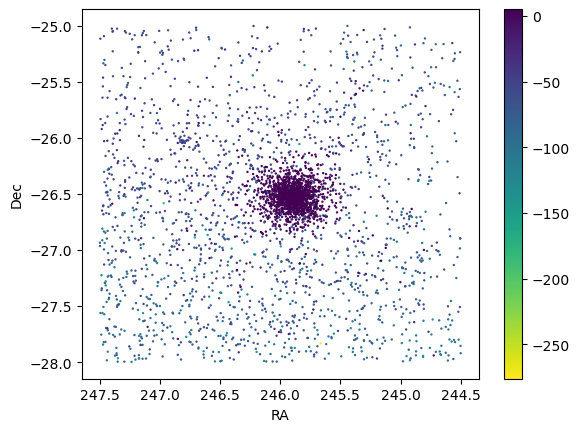

In [73]:
plt.scatter(ra[test_idx], dec[test_idx], c=jnp.diff(outputs, axis=1), s=0.5, cmap='viridis_r')
# plt.title('Balanced Dataset')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()
plt.colorbar()

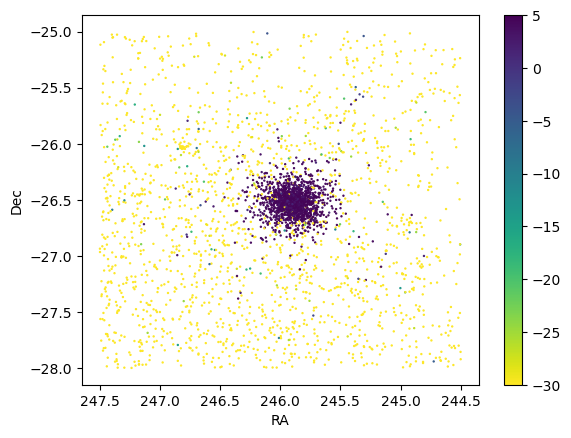

In [74]:
plt.scatter(ra[test_idx], dec[test_idx], c=jnp.diff(outputs, axis=1), s=0.5, cmap='viridis_r', vmin=-30, vmax=5)
# plt.title('Balanced Dataset with Proper Motion and Parallax')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()
plt.colorbar()
